![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
#%pip install pandas==2.2.3 numpy==1.26 matplotlib==3.9.4 scikit-learn==1.6.1 xgboost==2.1.4

In [3]:
# Importación de librerías

import pandas as pd
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

In [4]:
# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [5]:
# Eliminación filas con observaciones nulas
data.dropna(inplace=True)
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [6]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [7]:
# Codificación de las variables categoricas
X['M_Camry'] = pd.factorize(X.M_Camry)[0]
X['M_Camry4dr'] = pd.factorize(X.M_Camry4dr)[0]
X['M_CamryBase'] = pd.factorize(X.M_CamryBase)[0]
X['M_CamryL'] = pd.factorize(X.M_CamryL)[0]
X['M_CamryLE'] = pd.factorize(X.M_CamryLE)[0]
X['M_CamrySE'] = pd.factorize(X.M_CamrySE)[0]
X['M_CamryXLE'] = pd.factorize(X.M_CamryXLE)[0]

In [8]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42) 

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [9]:
# Celda 1
# Definición de parámetros y criterios de parada
max_depth = 3
num_pct = 10
min_gain=0.001

In [10]:

def var_reduction(x, y, split):
    left = y[x < split]
    right = y[x >= split]

    if len(left) == 0 or len(right) == 0:
        return 0

    total_var = np.var(y) * len(y)
    left_var = np.var(left) * len(left)
    right_var = np.var(right) * len(right)

    gain = total_var - (left_var + right_var)
    return gain


In [11]:
# Definición de la función best_split para calcular cuál es la mejor variable y punto de cortepara hacer la bifurcación del árbol

def best_split(X, y, num_pct=10):
    features = range(X.shape[1])
    best_split = [0, 0, -np.inf] 

    for j in features:
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:] 

        for split in splits:
            gain = var_reduction(X.iloc[:, j], y, split)
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

In [12]:
# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
        return tree
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = int(y.mean() >= 0.5) 
    y_prob = (y.sum() + 1.0) / (y.shape[0] + 2.0)  # Corrección Laplace 
    
    tree = dict(y_pred=y_pred, y_prob=y_prob, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree


In [13]:
# Definición de la función tree_predict para hacer predicciones según las variables 'X' y el árbol 'tree'

def tree_predict(X, tree, proba=False):
    
    predicted = np.ones(X.shape[0])

    # Revisar si es el nodo final
    if tree['split'] == -1:
        if not proba:
            predicted = predicted * tree['y_pred']
        else:
            predicted = predicted * tree['y_prob']
            
    else:
        
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:  # Si el nodo izquierdo está vacio solo continua con el derecho 
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)
        elif X_r.shape[0] == 0:  #  Si el nodo derecho está vacio solo continua con el izquierdo
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)

    return predicted


In [14]:
# Aplicación de la función tree_grow
tree = tree_grow(X_train, y_train, level=0, min_gain=0.001, max_depth=3, num_pct=10)
# Ejecución de función tree_predict
y_pred_tree=tree_predict(X_test, tree)

In [15]:
import matplotlib.pyplot as plt

def plot_custom_tree(tree, ax=None, x=0, y=0, dx=2.0, dy=4, level=0, max_depth=5, fontsize=5):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.axis('off')

    txt = f"Nivel {tree['level']}\n"
    txt += f"y_pred = {tree['y_pred']:.2f}\n"
    txt += f"ganancia = {tree['gain']:.2f}\n"
    if tree['split'] != -1:
        j, split = tree['split']
        txt += f"Split: x[{j}] < {split:.2f}"

    ax.text(x, -y, txt, ha='center', va='center',
            fontsize=fontsize,
            bbox=dict(boxstyle="round", facecolor='lavender'))

    if 'sl' in tree and tree['split'] != -1:
        next_dx = dx * 0.7 
        # izquierda
        ax.plot([x, x - dx], [-y, -y - dy], 'k-')
        plot_custom_tree(tree['sl'], ax, x - dx, y + dy, dx * 0.7, dy, level + 1)

        # derecha
        ax.plot([x, x + dx], [-y, -y - dy], 'k-')
        plot_custom_tree(tree['sr'], ax, x + dx, y + dy, dx * 0.7, dy, level + 1)

    if ax is None:
        plt.show()


Visualizacion de arbol manual

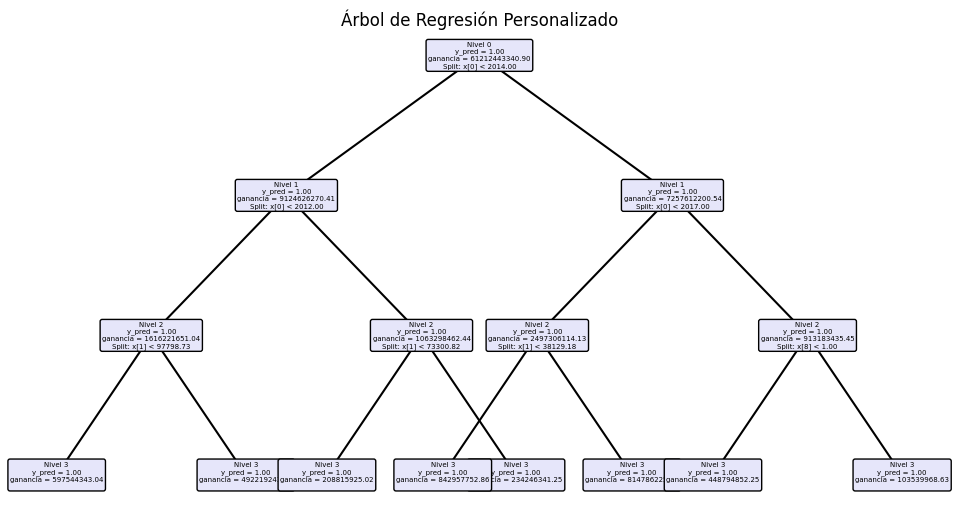

In [16]:
plot_custom_tree(tree)
plt.title("Árbol de Regresión Personalizado")
plt.show()

Calculo de mse y rmse

In [17]:
mse_arbol = metrics.mean_squared_error(y_test, y_pred_tree)
rmse_arbol = np.sqrt(mse_arbol)
print(f"RMSE del modelo de arbol de decisión manual: {rmse_arbol:.2f}")
print(f"MSE del modelo de árbol de decisión manual): {mse_arbol:.2f}")

RMSE del modelo de arbol de decisión manual: 15113.77
MSE del modelo de árbol de decisión manual): 228425960.60


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [18]:
# Creación de 10 muestras de bootstrap 


n_samples = X_train.shape[0]

n_arboles = 10

samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(1, n_arboles +1 )]

In [19]:

from sklearn.tree import DecisionTreeRegressor
# Definición del modelo base
treereg = DecisionTreeRegressor(max_depth=None, random_state=123)

# Variables independientes y dependiente
X_train_base = X_train.copy()
y_train_base = y_train.copy() 

# DataFrame para guardar predicciones
y_pred_bag = pd.DataFrame(index=X_test.index, columns=range(n_arboles))

# Entrenamiento con muestras bootstrap
for i, sample in enumerate(samples):
    X_bootstrap = X_train_base.iloc[sample, :]
    y_bootstrap = y_train_base.iloc[sample]      

    treereg.fit(X_bootstrap, y_bootstrap)
    #predecir sobre test
    y_pred_bag.iloc[:, i] = treereg.predict(X_test[X_bootstrap.columns])



In [20]:
# Desempeño de cada árbol
for i in range(n_arboles):
    print('El árbol ', i, 'tiene un error: ', np.sqrt(metrics.mean_squared_error(y_pred_bag.iloc[:,i], y_test)))

El árbol  0 tiene un error:  2158.8494304112705
El árbol  1 tiene un error:  2126.4743218987087
El árbol  2 tiene un error:  2165.870703907561
El árbol  3 tiene un error:  2141.4229853084594
El árbol  4 tiene un error:  2160.8048422833836
El árbol  5 tiene un error:  2038.4933089878186
El árbol  6 tiene un error:  2089.757210093292
El árbol  7 tiene un error:  2161.0326002992524
El árbol  8 tiene un error:  2194.53295149593
El árbol  9 tiene un error:  2097.430395523904


In [21]:
# Error al promediar las predicciones de todos los árboles
rmse_bagging=np.sqrt(metrics.mean_squared_error(y_test, y_pred_bag.mean(axis=1)))
mse_bagging=metrics.mean_squared_error(y_test, y_pred_bag.mean(axis=1))
print(f"RMSE del modelo Bagging (promedio de 10 árboles): {rmse_bagging:.2f}")
print(f"MSE del modelo Bagging (promedio de 10 árboles): {mse_bagging:.2f}")

RMSE del modelo Bagging (promedio de 10 árboles): 1800.02
MSE del modelo Bagging (promedio de 10 árboles): 3240068.09


### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [22]:
# Celda 3
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
n_features = X.shape[1]
max_features= int(np.log(n_features))



In [23]:
modelo_arbol= DecisionTreeRegressor()
modelo_bagging= BaggingRegressor(estimator=modelo_arbol,
                                 n_estimators=10,
                                 max_features=max_features,
                                 random_state=42,
                                 n_jobs=-1)

In [24]:
modelo_bagging.fit(X_train, y_train)
y_pred_bag_lib=modelo_bagging.predict(X_test)


In [25]:
mse_bag_lib =metrics.mean_squared_error(y_test, y_pred_bag_lib)
rmse_bag_lib= np.sqrt(metrics.mean_squared_error(y_test, y_pred_bag_lib))
print(f"RMSE del modelo Bagging con libreria: {rmse_bag_lib:.2f}")
print(f"MSE del modelo Bagging con libreria: {mse_bag_lib:.2f}")

RMSE del modelo Bagging con libreria: 2768.35
MSE del modelo Bagging con libreria: 7663764.02


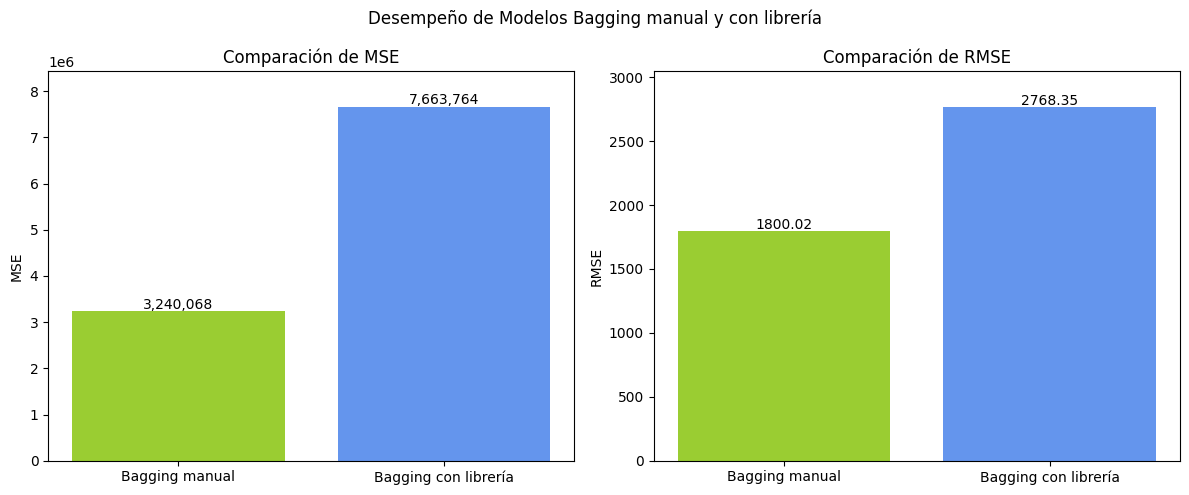

In [46]:
import matplotlib.pyplot as plt

# Métricas obtenidas
modelos = ['Bagging manual', 'Bagging con librería']
mse_valores = [mse_bagging, mse_bag_lib]
rmse_valores = [rmse_bagging, rmse_bag_lib]

# Crear la figura con dos subgráficas
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica de MSE
axs[0].bar(modelos, mse_valores, color=['yellowgreen', 'cornflowerblue'])
axs[0].set_title('Comparación de MSE')
axs[0].set_ylabel('MSE')
axs[0].set_ylim(0, max(mse_valores)*1.1)
for i, v in enumerate(mse_valores):
    axs[0].text(i, v + 50000, f"{v:,.0f}", ha='center', fontsize=10)

# Gráfica de RMSE
axs[1].bar(modelos, rmse_valores, color=['yellowgreen', 'cornflowerblue'])
axs[1].set_title('Comparación de RMSE')
axs[1].set_ylabel('RMSE')
axs[1].set_ylim(0, max(rmse_valores)*1.1)
for i, v in enumerate(rmse_valores):
    axs[1].text(i, v + 10, f"{v:.2f}", ha='center', fontsize=10)

plt.suptitle('Desempeño de Modelos Bagging manual y con librería')
plt.tight_layout()
plt.show()

**Reslutados con modelo bagging con librería:**

| | Bagging con librería | Bagging manual|
|:----:|:---------------:| :---------------:|
| MSE| 7663764.02| 3240068.09|
|RMSE|2768.35| 1800.02|

- El modelo Bagging implementado manualmente un desempeño significativamente mejor que el modelo Bagging con la librería de sklearn,  mostrando un MSE y RMSE considerablemente menores.
- Esta diferencia puede deberse a que en el modelo manual haya una mejor selección de las muestras de bootstrap o al hecho que los promedios ponderados sean más efectivos para el conjunto de decisiones.
- Finalmente, se puede suponer que la diferencia radica en el uso de `max_features` = `log(n_features)` por lo que influye directamente en la aprovechación de la información del dataset. Disminuir el valor de este parámetro (al igual que en el modelo manual) podría mejorar el desempeno del modelo.



### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [26]:
# Definición de modelo Random Forest para un problema de clasificación
from sklearn.ensemble import RandomForestRegressor
modelo_rf = RandomForestRegressor()

In [27]:
# Entrenamiento (fit) y desempeño del modeloRandom forest
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

In [28]:
mse_rf =metrics.mean_squared_error(y_test, y_pred_rf)
rmse_rf= np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf))
print(f"RMSE del modelo random forest con libreria: {rmse_rf:.2f}")
print(f"MSE del modelo random forest con libreria: {mse_rf:.2f}")

RMSE del modelo random forest con libreria: 1762.23
MSE del modelo random forest con libreria: 3105457.34


### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [43]:

from sklearn.model_selection import GridSearchCV

# Definir el modelo base
rf = RandomForestRegressor(random_state=42)

# Definir la malla de parámetros
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2', 0.5, 0.3, 1]
}

# Búsqueda de parámetros con validación cruzada
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train, y_train)

# Mostrar los mejores parámetros
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Evaluar el modelo final con test
mejor_modelo_calib= grid_search.best_estimator_
y_pred_rf_calib = mejor_modelo_calib.predict(X_test)
mse_rf_calib=metrics.mean_squared_error(y_test, y_pred_rf_calib)
rmse_rf_calib= np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf_calib))
print(f"RMSE del mejor modelo Random forest con libreria: {rmse_rf_calib:.2f}")
print(f"MSE del mejor modelo Random forest con libreria: {mse_rf_calib:.2f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Mejores parámetros encontrados:
{'max_depth': 10, 'max_features': 1, 'n_estimators': 150}
RMSE del mejor modelo Random forest con libreria: 1559.36
MSE del mejor modelo Random forest con libreria: 2431610.84


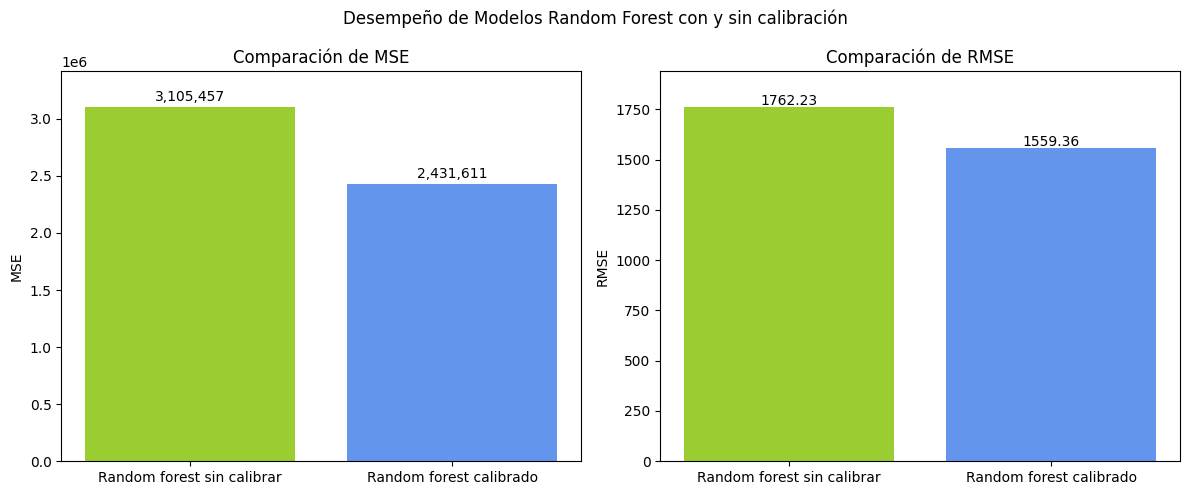

In [45]:
import matplotlib.pyplot as plt

# Métricas obtenidas
modelos = ['Random forest sin calibrar', 'Random forest calibrado']
mse_valores = [mse_rf, mse_rf_calib ]
rmse_valores = [rmse_rf, rmse_rf_calib]

# Crear la figura con dos subgráficas
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica de MSE
axs[0].bar(modelos, mse_valores, color=['yellowgreen', 'cornflowerblue'])
axs[0].set_title('Comparación de MSE')
axs[0].set_ylabel('MSE')
axs[0].set_ylim(0, max(mse_valores)*1.1)
for i, v in enumerate(mse_valores):
    axs[0].text(i, v + 50000, f"{v:,.0f}", ha='center', fontsize=10)

# Gráfica de RMSE
axs[1].bar(modelos, rmse_valores, color=['yellowgreen', 'cornflowerblue'])
axs[1].set_title('Comparación de RMSE')
axs[1].set_ylabel('RMSE')
axs[1].set_ylim(0, max(rmse_valores)*1.1)
for i, v in enumerate(rmse_valores):
    axs[1].text(i, v + 10, f"{v:.2f}", ha='center', fontsize=10)

plt.suptitle('Desempeño de Modelos Random Forest con y sin calibración')
plt.tight_layout()
plt.show()

**max_depth:**
El valor de max_depth indica  que tan complejo es el árbol al variar el número de niveles de este último. Un valor muy alto puede resultar en sobreajuste  al memorizar el ruido del entrenamiento. Un max_depth de 10 permitió la generalización del modelo.

**max_features:**
El valor de maxfeatures indica número de características consideradas en cada división lo que fecta la diversidad de los árboles. Un valor muy alto puede resultar en overfitting mientras que uno muy bajo puede resultar en underfitting. al considerar solo una característica aleatoria se redujo la correlación entre árboles para mejorar el desempeño.

**n_estimators**
Corresponde al número de árboles de decisión. Si se aumenta este parámetro  espera obtener un promedio más estable con una varianza reducida. Con un `n_estimators` =150 se reudjo la varianza manteniendo una velocidada aceptable.

**Comparación de modelos**

| | Random forest sin calibración | Random forest con calibraciön |
|:----:|:---------------:|:---------------:|
| MSE| 3105457.34|2431611|
|RMSE|1762.23 |1559.36 |


- Desempeño sin calibración: El modelo base de F, sin ajustes, presentó un RMSE de 1762.23 y un MSE de  3105457.34, lo que sugiere una tendencia al sobreajuste o subóptima selección de características y profundidad.
- Desempeño con calibración: Luego de calibrar learning_rate, gamma y colsample_bytree, el modelo logró mejorar disminuir su error, con un RMSE (1559.36) y MSE (2431611)  levemente más  bajo, logrando así un mejor equilibrio entre sesgo y varianza.
-La calibración de hiperparámetros tuvo un impacto positivo positivo en la eficiencia y la generalización del modelo.
Reducir la profundidad y controlar cuántas características se usan por división ayudó a balancear el sesgo y la varianza por lo que el modelo calibrado es claramente superior al modelo sin ajustes, tanto en términos de error como de estabilidad.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [33]:
# Celda 6
# Importación y definición de modelo XGBregressor
from xgboost import XGBRegressor
modelo_xgb = XGBRegressor()
modelo_xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Entrenamiento (fit) y desempeño del modelo XGBClassifier
modelo_xgb.fit(X_train, y_train)
y_pred_xgb = modelo_xgb.predict(X_test)

mse_xgb=metrics.mean_squared_error(y_test, y_pred_xgb)
rmse_xgb= np.sqrt(metrics.mean_squared_error(y_test, y_pred_xgb))
print(f"RMSE del modelo XGBoosting con libreria: {rmse_xgb:.2f}")
print(f"MSE del modelo XGBoosting con libreria: {mse_xgb:.2f}")

RMSE del modelo Bagging con libreria: 1605.24
MSE del modelo Bagging con libreria: 2576781.00


### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [38]:
param_grid = {
    'learning_rate': [0.01, 0.05,0.1, 0.2],
    'gamma': [0, 1, 5, 7],
    'colsample_bytree': [0.3, 0.5,0.7, 1]
}
grid_search = GridSearchCV(estimator=modelo_xgb,
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1,
                           verbose=1)

# Entrenar
grid_search.fit(X_train, y_train)

# Evaluar
mejor_modelo_xgb = grid_search.best_estimator_
y_pred_xgb_cailib = mejor_modelo_xgb.predict(X_test)
mse_xgb_calib = metrics.mean_squared_error(y_test, y_pred_xgb_cailib)
rmse_xgb_calib = np.sqrt(mse_xgb_calib)

# Resultados
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)
print(f"MSE del mejor modelo XGBoosting con libreria: {mse_xgb_calib:.2f}")
print(f"RMSE del mejor modelo XGBoosting con lireria: {rmse_xgb_calib:.2f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Mejores parámetros encontrados:
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.05}
MSE del mejor modelo XGBoosting con libreria: 2385957.75
RMSE del mejor modelo XGBoosting con lireria: 1544.65


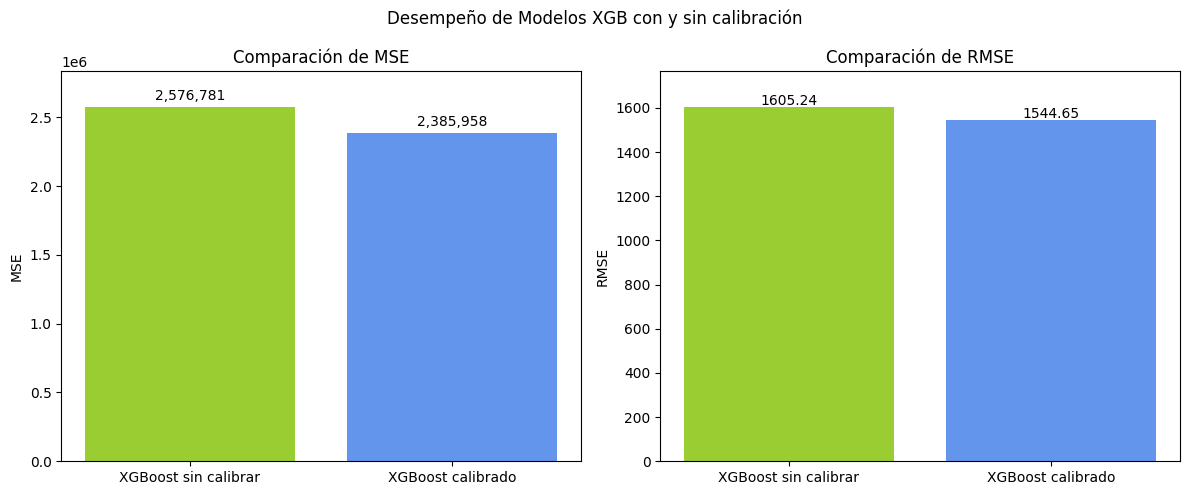

In [44]:
import matplotlib.pyplot as plt

# Métricas obtenidas
modelos = ['XGBoost sin calibrar', 'XGBoost calibrado']
mse_valores = [mse_xgb, mse_xgb_calib ]
rmse_valores = [rmse_xgb, rmse_xgb_calib]

# Crear la figura con dos subgráficas
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica de MSE
axs[0].bar(modelos, mse_valores, color=['yellowgreen', 'cornflowerblue'])
axs[0].set_title('Comparación de MSE')
axs[0].set_ylabel('MSE')
axs[0].set_ylim(0, max(mse_valores)*1.1)
for i, v in enumerate(mse_valores):
    axs[0].text(i, v + 50000, f"{v:,.0f}", ha='center', fontsize=10)

# Gráfica de RMSE
axs[1].bar(modelos, rmse_valores, color=['yellowgreen', 'cornflowerblue'])
axs[1].set_title('Comparación de RMSE')
axs[1].set_ylabel('RMSE')
axs[1].set_ylim(0, max(rmse_valores)*1.1)
for i, v in enumerate(rmse_valores):
    axs[1].text(i, v + 10, f"{v:.2f}", ha='center', fontsize=10)

plt.suptitle('Desempeño de Modelos XGB con y sin calibración')
plt.tight_layout()
plt.show()


El ajuste de hiperparámetros consiste en identificar y seleccionar los hiperparámetros óptimos para el entrenamiento del modelo XGBoosting. En este caso los parámetros a calibrar fueron learning_rate, gamma y colsample_bytree.

**learning_rate:**
En términos genrales este parámetro permite definbir que tanto contribuye el cada árbol al resultado final.Una tasa de aprendizaje alta significa que un modelo se ajustará más rápidamente, pero con el riesgo de ofrecer un rendimiento inestable y una desviación de los datos. Una tasa baja en cambio se demora más y requiere más arboles pero previene el sobreajuste.
EN este caso el `learning_rate` (0.05) se considera moderado lo que permitió mejorar la precisión sin sacrificar generalización.

**gamma:**
El valor de gamma corresponde a la reducción de pérdida mínima necesaria para realizar una partición mayor en un nodo de hoja del árbol por lo que controla la complejidad de los árboles, penalizando divisiones poco relevantes. Al tener `gamma` =0  lo que permite una mayor flexibilidad del modelo aunque aumenta el riesgo de sobreajuste.

**colsample_bytree**
Este parámetro define la proporción de columna utilizadas en cada árbol. Entre más bajo más se reduce el riesgo de sobreajuste mientras que entre más cercano a 1 pueden usarse más variables que pueden ser irrelevantes. Al ser `olsample_bytree` =0.7 podemos concluir que su valor intermedio permitió un balance adecuado entre varianza y sesgo.

| | XGB sin calibración | XGB con calibraciön |
|:----:|:---------------:|:---------------:|
| MSE| 2576781.00|2385957.75|
|RMSE|1605.24 |1544.65 |


**Comparación de modelos**
- Desempeño sin calibración: El modelo base de XGBoost, sin ajustes, presentó un RMSE de 1605.24 y un MSE de  2576781, lo que indica errores significativos al predecir en el set de prueba.
- Desempeño con calibración: Luego de calibrar learning_rate, gamma y colsample_bytree, el modelo logró mejorar disminuir su error, con un RMSE (1545) y MSE (2385958)  más bajo, lo que se traduce en mejor capacidad de generalización y menor sobreajuste.
- Al no ser un cambio drástico se puede suponer que el modelo inicial tenía buen calibre o que la calibración no fue tan eficiente.

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

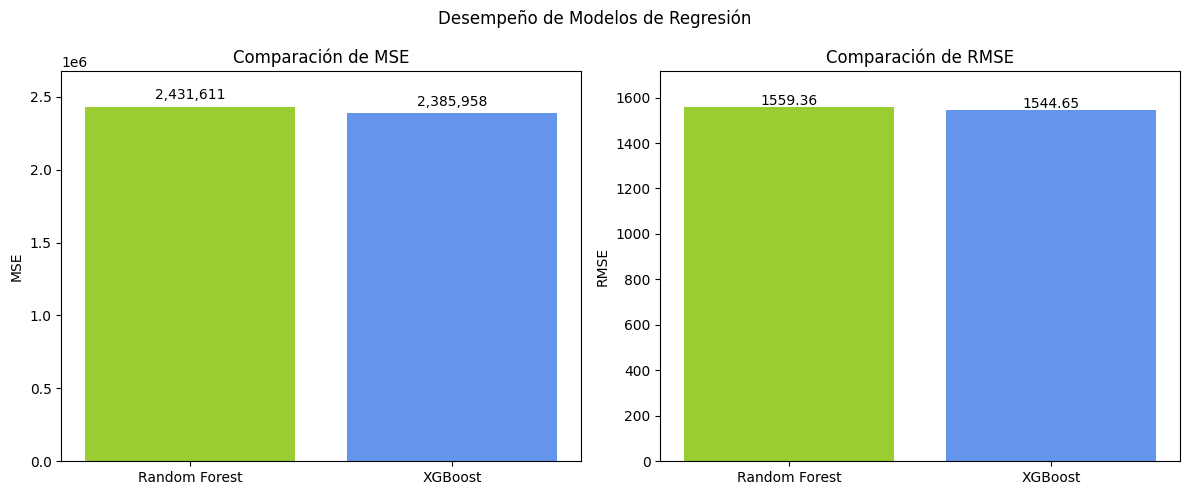

In [42]:

import matplotlib.pyplot as plt

# Métricas obtenidas
modelos = ['Random Forest', 'XGBoost']
mse_valores = [mse_rf_calib, mse_xgb_calib ]
rmse_valores = [rmse_rf_calib, rmse_xgb_calib]

# Crear la figura con dos subgráficas
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica de MSE
axs[0].bar(modelos, mse_valores, color=['yellowgreen', 'cornflowerblue'])
axs[0].set_title('Comparación de MSE')
axs[0].set_ylabel('MSE')
axs[0].set_ylim(0, max(mse_valores)*1.1)
for i, v in enumerate(mse_valores):
    axs[0].text(i, v + 50000, f"{v:,.0f}", ha='center', fontsize=10)

# Gráfica de RMSE
axs[1].bar(modelos, rmse_valores, color=['yellowgreen', 'cornflowerblue'])
axs[1].set_title('Comparación de RMSE')
axs[1].set_ylabel('RMSE')
axs[1].set_ylim(0, max(rmse_valores)*1.1)
for i, v in enumerate(rmse_valores):
    axs[1].text(i, v + 10, f"{v:.2f}", ha='center', fontsize=10)

plt.suptitle('Desempeño de Modelos de Regresión')
plt.tight_layout()
plt.show()


**Compración**
Al caluclae los errores de ambos modelosodemos ver que el MSE de random forest (2,431,611) es levemente superior al de XGBoost (2,385,968). de igual manera el RMSE de random forest (1559) también es levemente mayor al de CGBoost (1544). Un menor valor en esta métrica indica un mejor desempeño por lo que se puede afirmar que el modelo XGBoost es mejor. Sin embargo, al no ser diferencias considerables entre los erroes se puede adumir tambien que la diferencia en desempeño tampoco es muy grande.

**Ventajas XGBoosting**
El XGBoosting tiene una mejor precisión con respecto a random forest. Su hiperparámetros `learning_rate`, `gamma`, y `colsample_bytree` permiten calibrar el modelo para obtener mejores resultados y así controlar el aprendizaje. También sus mecanismo de de regularización le permiten disminuir el overfitting.

**Desventajas Random Forest**
EL modelo de Random Forest tiene tendencia a sobreajustar si no se determinan bien sus parámetros `max_depth`, `max_features` y `n_estimators`. De igual manera, es menos flexible cuando se utilizan conjuntos de datos más grandes.

**Referencias**
- "Optimización de hiperparámetros de un clasificador de Machine Learning en Python" de  https://panamahitek.com/optimizacion-de-hiperparametros-machine-learning/
- "XGBoost hiperparámetros
", de: https://docs.aws.amazon.com/es_es/sagemaker/latest/dg/xgboost_hyperparameters.html
- "¿Qué es el ajuste de hiperparámetros?", de: https://www.ibm.com/es-es/think/topics/hyperparameter-tuning
- "XGBoost Parameters", de: https://xgboost.readthedocs.io/en/stable/parameter.html 
- "Random Forest Classification with Scikit-Learn" de https://www.datacamp.com/tutorial/random-forests-classifier-python